In [1]:
!pip uninstall -y scikit-learn scikeras
!pip install scikit-learn==1.4.2
!pip install scikeras==0.13.0

import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


Task 1: Dataset Exploration

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1. Loaded the dataset

2. Dataset dimensions:

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,) 

3. Displaying ten sample images:



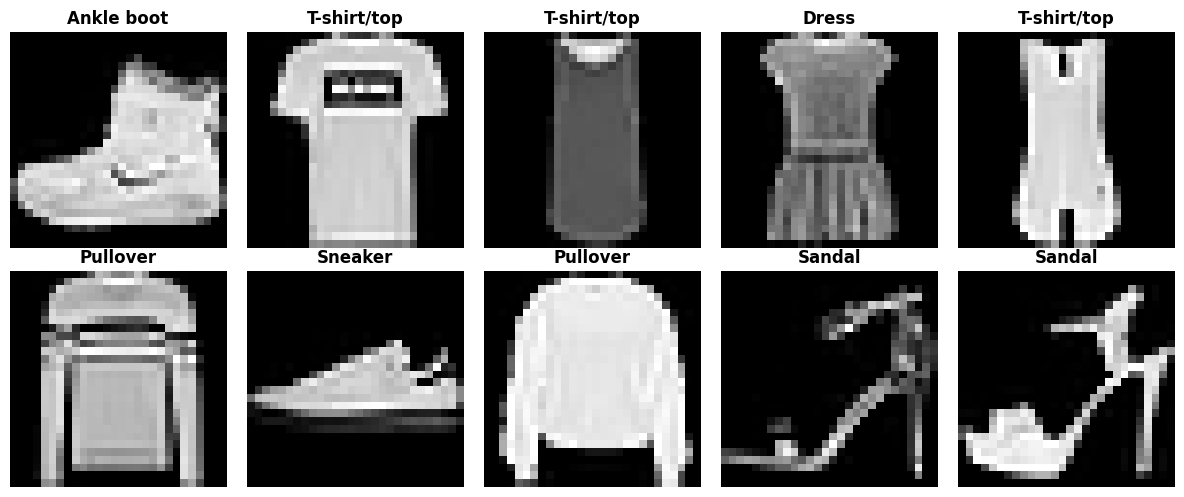


4. Class distribution:



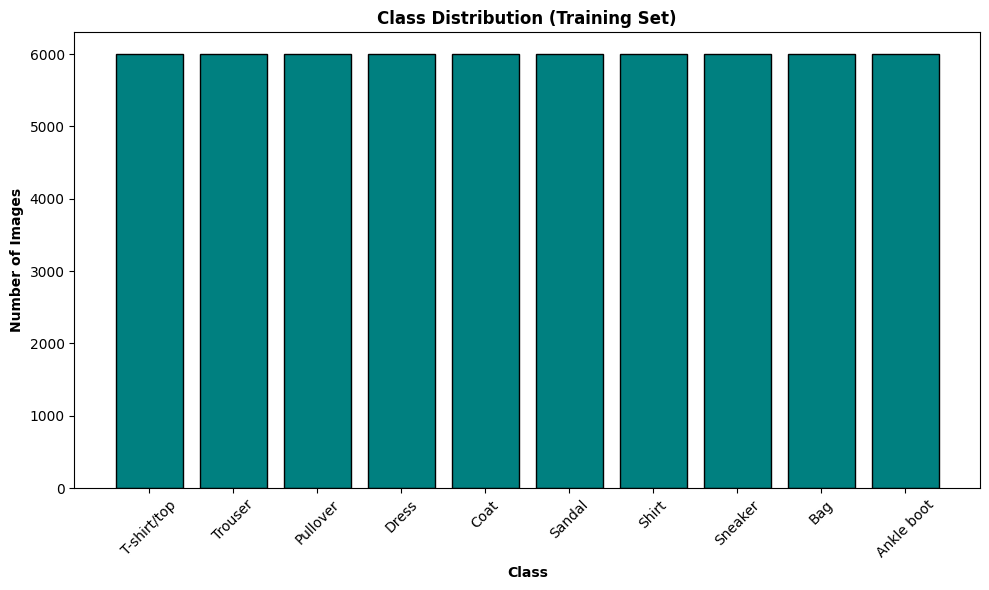

In [2]:
print("Task 1: Dataset Exploration\n")



from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("1. Loaded the dataset\n")
print("2. Dataset dimensions:\n")
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape, "\n")

print("3. Displaying ten sample images:\n")
plt.figure(figsize=(12,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title(class_names[y_train[i]], fontweight="bold")
  plt.axis("off")
plt.tight_layout()
plt.savefig("sample_images.eps", dpi=600)
plt.show()
print()

print("4. Class distribution:\n")
classes, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10,6))
plt.bar([class_names[c] for c in classes], counts, color="teal", edgecolor="black")
plt.xlabel("Class", fontweight="bold")
plt.ylabel("Number of Images", fontweight="bold")
plt.title("Class Distribution (Training Set)", fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.eps", dpi=600)
plt.show()

In [3]:
print("Task 2: Data Preprocessing\n")

print("Shape before preprocessing:")
print("X_train:", X_train.shape, " X_test:", X_test.shape, "\n")

# Flatten each 28x28 image into a 784-length vector, since Dense layers need 1D input
X_train_flat = X_train.reshape(X_train.shape[0], 784)
X_test_flat = X_test.reshape(X_test.shape[0], 784)

# Normalize pixel values from [0,255] to [0,1]
X_train_norm = X_train_flat.astype("float32") / 255.0
X_test_norm = X_test_flat.astype("float32") / 255.0

# One-hot encode the labels for the Softmax + Categorical Cross Entropy setup
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Shape after preprocessing:")
print("X_train:", X_train_norm.shape, " X_test:", X_test_norm.shape)
print("y_train:", y_train_cat.shape, " y_test:", y_test_cat.shape)

Task 2: Data Preprocessing

Shape before preprocessing:
X_train: (60000, 28, 28)  X_test: (10000, 28, 28) 

Shape after preprocessing:
X_train: (60000, 784)  X_test: (10000, 784)
y_train: (60000, 10)  y_test: (10000, 10)


In [4]:
print("Task 3: Model Construction\n")



model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

Task 3: Model Construction



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
print("Task 4: Model Training\n")


model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

start_time = time.time()
history = model.fit(
    X_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)
baseline_training_time = time.time() - start_time

print("\nTraining time:", round(baseline_training_time, 2), "seconds")

Task 4: Model Training

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8213 - loss: 0.5068 - val_accuracy: 0.8452 - val_loss: 0.4158
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8630 - loss: 0.3773 - val_accuracy: 0.8495 - val_loss: 0.4034
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8744 - loss: 0.3400 - val_accuracy: 0.8660 - val_loss: 0.3531
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8836 - loss: 0.3160 - val_accuracy: 0.8680 - val_loss: 0.3501
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8909 - loss: 0.2956 - val_accuracy: 0.8730 - val_loss: 0.3334
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8959 - loss: 0.2799 - val_accuracy: 0.8682 - val_loss: 0.3535
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8990 - loss: 0.2693 - val_accuracy: 0.8820 - val_loss: 0.3364
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy:

Training and Validation Curves



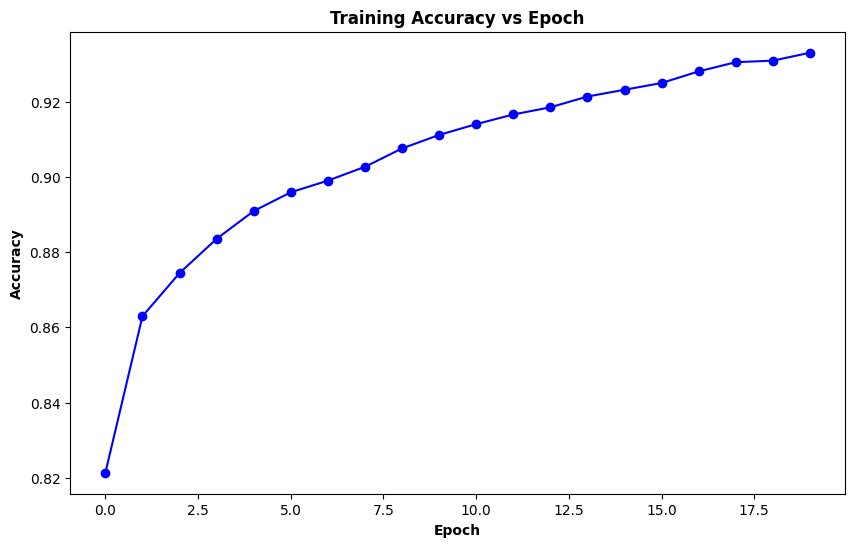

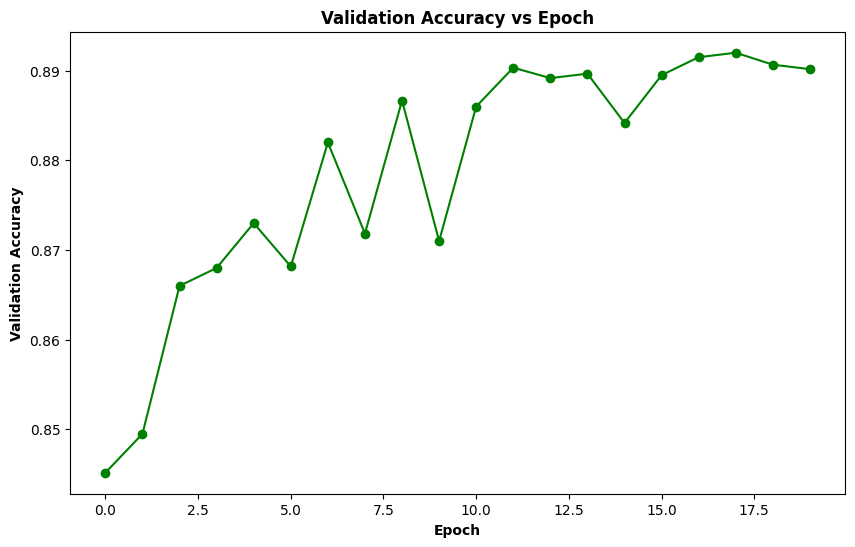

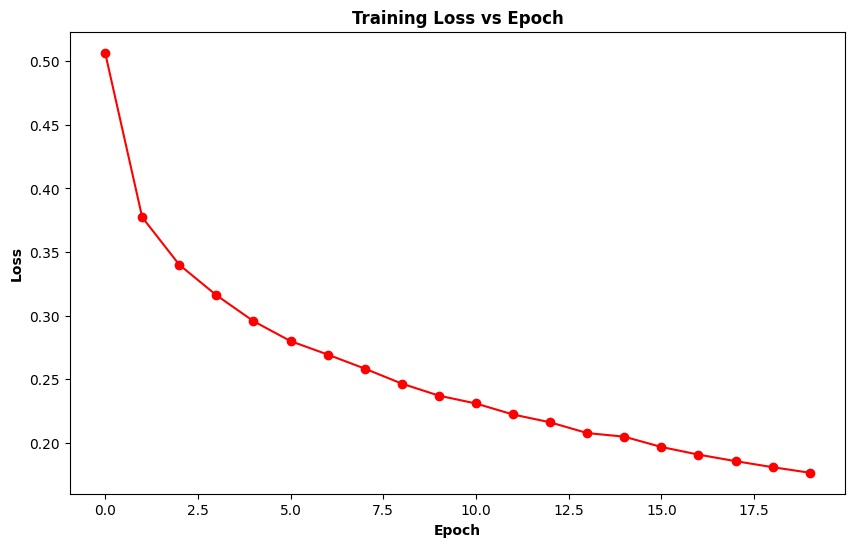

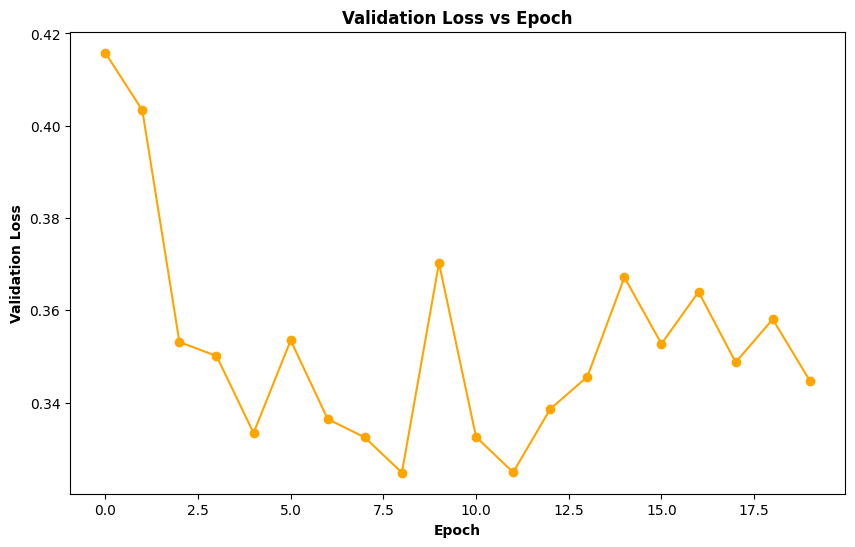

In [6]:
print("Training and Validation Curves\n")

# Training Accuracy vs Epoch
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], marker="o", color="blue")
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Accuracy", fontweight="bold")
plt.title("Training Accuracy vs Epoch", fontweight="bold")
plt.savefig("training_accuracy.eps", dpi=600)
plt.show()
print()

# Validation Accuracy vs Epoch
plt.figure(figsize=(10,6))
plt.plot(history.history["val_accuracy"], marker="o", color="green")
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Validation Accuracy", fontweight="bold")
plt.title("Validation Accuracy vs Epoch", fontweight="bold")
plt.savefig("validation_accuracy.eps", dpi=600)
plt.show()
print()

# Training Loss vs Epoch
plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], marker="o", color="red")
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")
plt.title("Training Loss vs Epoch", fontweight="bold")
plt.savefig("training_loss.eps", dpi=600)
plt.show()
print()

# Validation Loss vs Epoch
plt.figure(figsize=(10,6))
plt.plot(history.history["val_loss"], marker="o", color="orange")
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Validation Loss", fontweight="bold")
plt.title("Validation Loss vs Epoch", fontweight="bold")
plt.savefig("validation_loss.eps", dpi=600)
plt.show()

Task 5: Model Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy:  0.8851
Precision:  0.8852080078349358
Recall:  0.8851
F1 Score:  0.8846446717628381 

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.86      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.83      0.81      1000
       Dress       0.90      0.88      0.89      1000
        Coat       0.80      0.82      0.81      1000
      Sandal       0.95      0.98      0.96      1000
       Shirt       0.74      0.65      0.69      1000
     Sneaker       0.96      0.94      0.95      1000
         Bag       0.98      0.95      0.96      1000
  Ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000



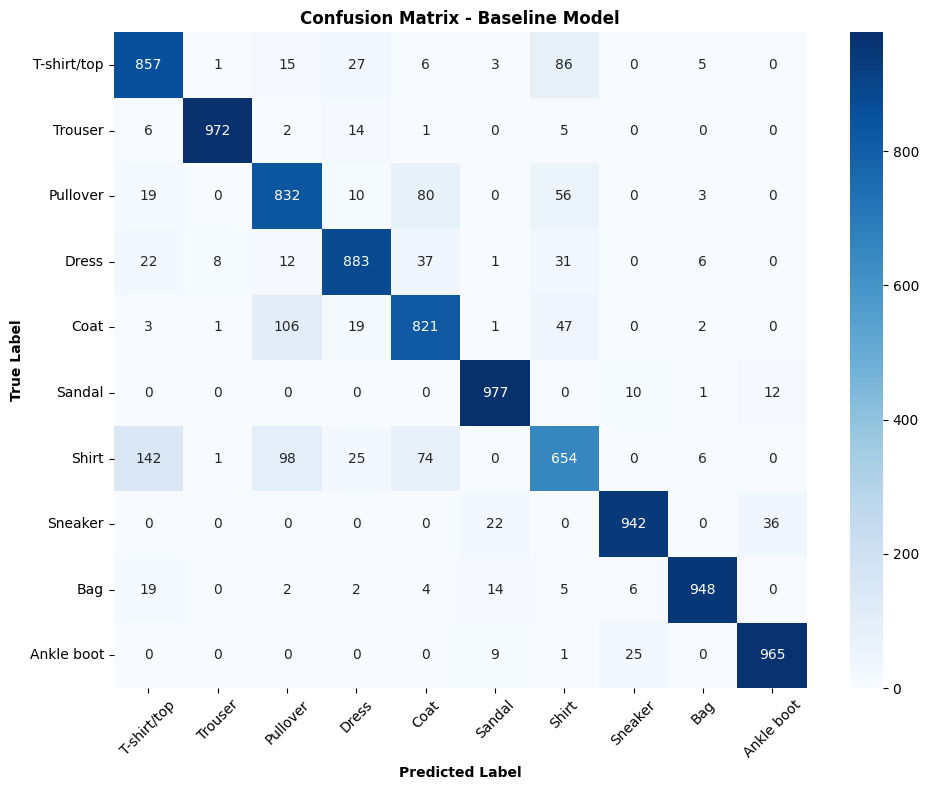

In [7]:
print("Task 5: Model Evaluation\n")



y_pred_prob = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_prob, axis=1)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred, average="weighted")
baseline_recall = recall_score(y_test, y_pred, average="weighted")
baseline_f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy: ", baseline_accuracy)
print("Precision: ", baseline_precision)
print("Recall: ", baseline_recall)
print("F1 Score: ", baseline_f1, "\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")
plt.title("Confusion Matrix - Baseline Model", fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.eps", dpi=600)
plt.show()

In [8]:
print("Hyperparameter Optimization\n")

print("1. Baseline model: already built (Task 3) and trained (Task 4) above\n")
print("2. Defining the hyperparameter search space and a model-builder function for SciKeras\n")

def build_model(hidden_layers=2, neurons=64, learning_rate=0.001, optimizer_name="adam", activation="relu", dropout=0.0):
  model = Sequential()
  model.add(Dense(neurons, activation=activation, input_shape=(784,)))
  if dropout > 0:
    model.add(Dropout(dropout))
  for _ in range(hidden_layers - 1):
    model.add(Dense(neurons, activation=activation))
    if dropout > 0:
      model.add(Dropout(dropout))
  model.add(Dense(10, activation="softmax"))

  if optimizer_name == "sgd":
    opt = SGD(learning_rate=learning_rate)
  elif optimizer_name == "rmsprop":
    opt = RMSprop(learning_rate=learning_rate)
  else:
    opt = Adam(learning_rate=learning_rate)

  model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
  return model

param_distributions = {
    "model__hidden_layers": [1, 2, 3],
    "model__neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
    "model__optimizer_name": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout": [0.0, 0.2, 0.5],
}

# NOTE: A full RandomizedSearchCV with 5-fold CV over all 60,000 training
# images is extremely expensive on CPU, since each candidate trains a full
# model up to 5 times. To keep the search runnable, it is performed here on a
# stratified subset of the training data (SEARCH_SAMPLE_SIZE). Set
# SEARCH_SAMPLE_SIZE = 60000 to search on the full training set if a GPU / more
# time is available. The FINAL best model is always retrained on the FULL
# training set afterwards (see next cell), so this only affects the search step.
SEARCH_SAMPLE_SIZE = 10000

X_search, _, y_search, _ = train_test_split(
    X_train_norm, y_train_cat, train_size=SEARCH_SAMPLE_SIZE,
    stratify=y_train, random_state=42
)

print("3. Performing Randomized Search with 5-fold cross-validation\n")

clf = KerasClassifier(model=build_model, verbose=0)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=1
)

search_start = time.time()
search.fit(X_search, y_search)
search_time = time.time() - search_start

print("\nSearch completed in", round(search_time, 2), "seconds\n")
print("4. Best hyperparameter combination found:\n")
print(search.best_params_)
print("\nBest cross-validation accuracy:", search.best_score_)

Hyperparameter Optimization

1. Baseline model: already built (Task 3) and trained (Task 4) above

2. Defining the hyperparameter search space and a model-builder function for SciKeras

3. Performing Randomized Search with 5-fold cross-validation

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=   9.6s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=   9.5s


...

[CV] END batch_size=32, epochs=30, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.01, model__neurons=128, model__optimizer_name=adam; total time=  21.5s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=32, epochs=30, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.01, model__neurons=128, model__optimizer_name=adam; total time=  20.7s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Search completed in 1633.11 seconds

4. Best hyperparameter combination found:

{'model__optimizer_name': 'adam', 'model__neurons': 256, 'model__learning_rate': 0.001, 'model__hidden_layers': 2, 'model__dropout': 0.0, 'model__activation': 'sigmoid', 'epochs': 30, 'batch_size': 32}

Best cross-validation accuracy: 0.8600000000000001


5. Retraining the optimized model on the full training set

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8061 - loss: 0.5451 - val_accuracy: 0.8503 - val_loss: 0.4056
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8610 - loss: 0.3830 - val_accuracy: 0.8570 - val_loss: 0.3911
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8745 - loss: 0.3438 - val_accuracy: 0.8702 - val_loss: 0.3500
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8839 - loss: 0.3179 - val_accuracy: 0.8720 - val_loss: 0.3590
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8903 - loss: 0.2978 - val_accuracy: 0.8815 - val_loss: 0.3212
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8948 - loss: 0.2801 - val_accuracy: 0.8860 - val_loss: 0.3071
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9001 - loss: 0.2666 - val_accuracy: 0.8793 - val_loss: 0.3213
Epoch 8/30
1688/1688 ━━━━━━━━━

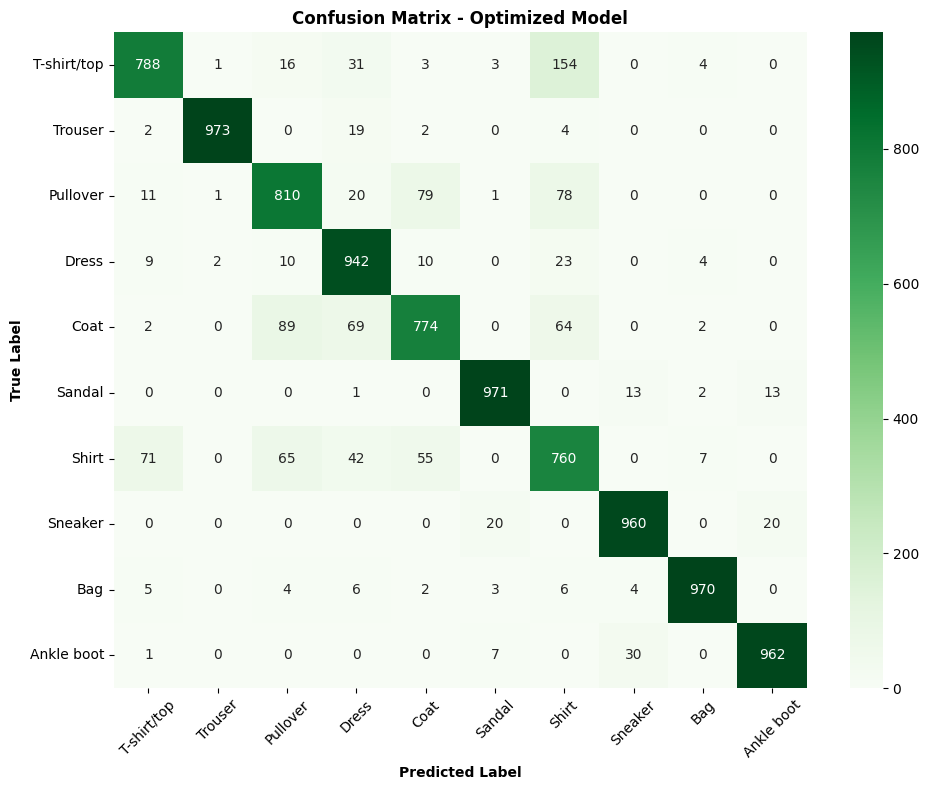

In [9]:
print("5. Retraining the optimized model on the full training set\n")

best = search.best_params_

optimized_model = build_model(
    hidden_layers=best["model__hidden_layers"],
    neurons=best["model__neurons"],
    learning_rate=best["model__learning_rate"],
    optimizer_name=best["model__optimizer_name"],
    activation=best["model__activation"],
    dropout=best["model__dropout"]
)

start_time = time.time()
optimized_history = optimized_model.fit(
    X_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=best["epochs"],
    batch_size=best["batch_size"],
    verbose=1
)
optimized_training_time = time.time() - start_time
print("\nTraining time:", round(optimized_training_time, 2), "seconds")

print("\n6. Evaluating the optimized model on the testing dataset\n")

y_pred_opt_prob = optimized_model.predict(X_test_norm)
y_pred_opt = np.argmax(y_pred_opt_prob, axis=1)

optimized_accuracy = accuracy_score(y_test, y_pred_opt)
optimized_precision = precision_score(y_test, y_pred_opt, average="weighted")
optimized_recall = recall_score(y_test, y_pred_opt, average="weighted")
optimized_f1 = f1_score(y_test, y_pred_opt, average="weighted")

print("Accuracy: ", optimized_accuracy)
print("Precision: ", optimized_precision)
print("Recall: ", optimized_recall)
print("F1 Score: ", optimized_f1, "\n")

print(classification_report(y_test, y_pred_opt, target_names=class_names))

cm_opt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(10,8))
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")
plt.title("Confusion Matrix - Optimized Model", fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_optimized.eps", dpi=600)
plt.show()

In [10]:
print("7. Comparing the optimized model with the baseline model\n")


comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Training Time (s)"],
    "Baseline": [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, round(baseline_training_time, 2)],
    "Optimized": [optimized_accuracy, optimized_precision, optimized_recall, optimized_f1, round(optimized_training_time, 2)]
})
print(comparison)

7. Comparing the optimized model with the baseline model

              Metric    Baseline   Optimized
0           Accuracy    0.885100    0.891000
1          Precision    0.885208    0.893258
2             Recall    0.885100    0.891000
3           F1-score    0.884645    0.891235
4  Training Time (s)  113.460000  151.390000


Hyperparameter Search Results and Best Model Comparison



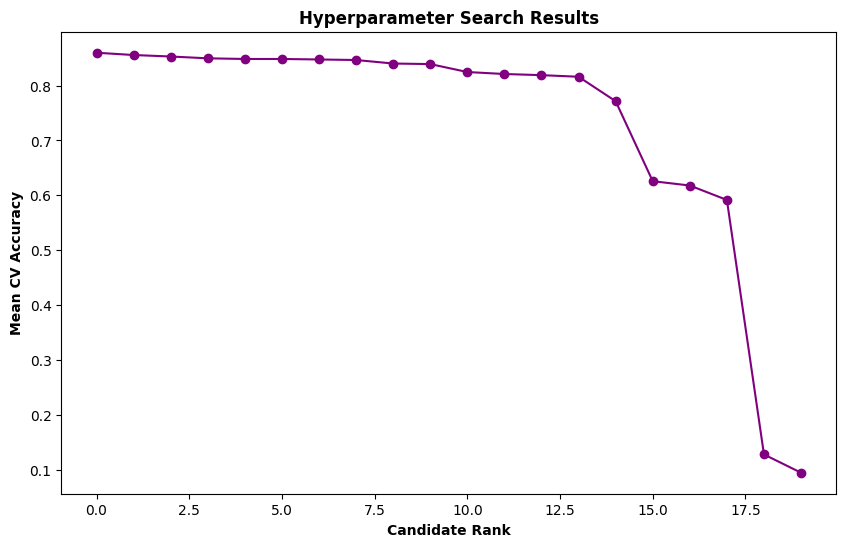

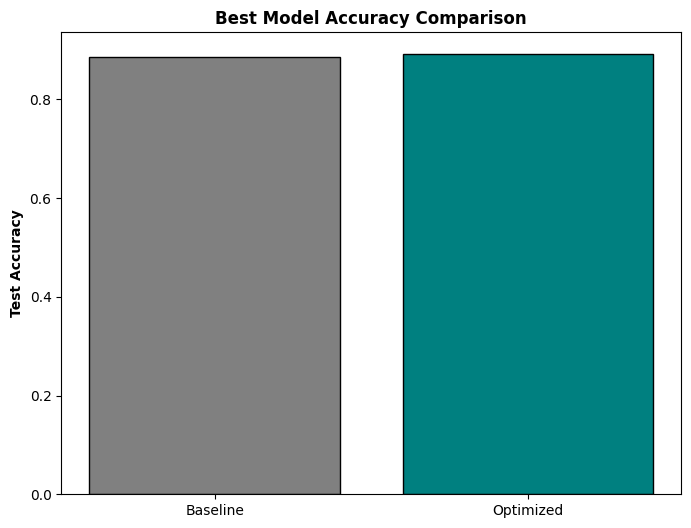

In [11]:
print("Hyperparameter Search Results and Best Model Comparison\n")

# Hyperparameter Search Results - mean CV accuracy for each candidate tried, best first
results_df = pd.DataFrame(search.cv_results_).sort_values("mean_test_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10,6))
plt.plot(results_df.index, results_df["mean_test_score"], marker="o", color="purple")
plt.xlabel("Candidate Rank", fontweight="bold")
plt.ylabel("Mean CV Accuracy", fontweight="bold")
plt.title("Hyperparameter Search Results", fontweight="bold")
plt.savefig("hyperparameter_search_results.eps", dpi=600)
plt.show()
print()

# Best Model Accuracy Comparison
plt.figure(figsize=(8,6))
plt.bar(["Baseline", "Optimized"], [baseline_accuracy, optimized_accuracy], color=["gray", "teal"], edgecolor="black")
plt.ylabel("Test Accuracy", fontweight="bold")
plt.title("Best Model Accuracy Comparison", fontweight="bold")
plt.savefig("best_model_accuracy_comparison.eps", dpi=600)
plt.show()